In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kasvirajwar","key":"cff9c045f139a5cc0082ee4ccaf324b4"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [ ]:
!pip install kaggle
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Dataset/Validation/Real/real_5499.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_55.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_550.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5500.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5501.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5502.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5503.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5504.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5505.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5506.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5507.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5508.jpg  
  inflating: /content/dataset/Dataset/Validation/Real/real_5509.jpg  
  inflating: /content/dataset/Dataset/Vali

In [ ]:
import os

base_dir = '/content/dataset/Dataset'

for split in os.listdir(base_dir):
    split_path = os.path.join(base_dir, split)
    for category in os.listdir(split_path):
        cat_path = os.path.join(split_path, category)
        print(f"{split}/{category}: {len(os.listdir(cat_path))} images")

Test/Fake: 5492 images
Test/Real: 5413 images
Validation/Fake: 19641 images
Validation/Real: 19787 images
Train/Fake: 70001 images
Train/Real: 70001 images


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    '/content/dataset/Dataset/Train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_data = datagen.flow_from_directory(
    '/content/dataset/Dataset/Validation',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7552 - loss: 0.4941

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 245s 52ms/step - accuracy: 0.7552 - loss: 0.4941 - val_accuracy: 0.7961 - val_loss: 0.4327
Epoch 2/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7883 - loss: 0.4407

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 189s 43ms/step - accuracy: 0.7883 - loss: 0.4407 - val_accuracy: 0.7965 - val_loss: 0.4296
Epoch 3/10
4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7957 - loss: 0.4301

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 190s 43ms/step - accuracy: 0.7957 - loss: 0.4301 - val_accuracy: 0.8037 - val_loss: 0.4203
Epoch 4/10
4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7983 - loss: 0.4276

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 191s 44ms/step - accuracy: 0.7983 - loss: 0.4276 - val_accuracy: 0.8097 - val_loss: 0.4104
Epoch 5/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 196s 45ms/step - accuracy: 0.8006 - loss: 0.4182 - val_accuracy: 0.8088 - val_loss: 0.4150
Epoch 6/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 190s 43ms/step - accuracy: 0.8049 - loss: 0.4139 - val_accuracy: 0.8094 - val_loss: 0.4149
Epoch 7/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8056 - loss: 0.4142

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 190s 43ms/step - accuracy: 0.8056 - loss: 0.4142 - val_accuracy: 0.8130 - val_loss: 0.4109


In [ ]:
import tensorflow as tf

# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8014 - loss: 0.4262

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 226s 48ms/step - accuracy: 0.8014 - loss: 0.4262 - val_accuracy: 0.8612 - val_loss: 0.3297
Epoch 2/5
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8748 - loss: 0.2883

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 194s 44ms/step - accuracy: 0.8748 - loss: 0.2883 - val_accuracy: 0.8740 - val_loss: 0.3006
Epoch 3/5
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8984 - loss: 0.2412

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 194s 44ms/step - accuracy: 0.8984 - loss: 0.2412 - val_accuracy: 0.8887 - val_loss: 0.2695
Epoch 4/5
4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9107 - loss: 0.2110

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 188s 43ms/step - accuracy: 0.9107 - loss: 0.2110 - val_accuracy: 0.8957 - val_loss: 0.2577
Epoch 5/5
4375/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9217 - loss: 0.1867

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 191s 44ms/step - accuracy: 0.9217 - loss: 0.1867 - val_accuracy: 0.8999 - val_loss: 0.2587


In [ ]:
test_data = datagen.flow_from_directory(
    '/content/dataset/Dataset/Test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

loss, accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Found 10905 images belonging to 2 classes.
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.8556 - loss: 0.3758

Test Accuracy: 77.52%
Test Loss: 0.7050


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# New datagen WITH augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Validation and test still just rescaled, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_data2 = train_datagen.flow_from_directory(
    '/content/dataset/Dataset/Train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

val_data2 = test_datagen.flow_from_directory(
    '/content/dataset/Dataset/Validation',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_data2 = test_datagen.flow_from_directory(
    '/content/dataset/Dataset/Test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Rebuild model
base_model2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model2.trainable = False

model2 = Sequential([
    base_model2,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint2 = ModelCheckpoint('best_model2.h5', save_best_only=True, monitor='val_accuracy')

history3 = model2.fit(
    train_data2,
    epochs=10,
    validation_data=val_data2,
    callbacks=[early_stop2, checkpoint2]
)

Epoch 1/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7343 - loss: 0.5292

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 786s 177ms/step - accuracy: 0.7343 - loss: 0.5292 - val_accuracy: 0.7676 - val_loss: 0.4761
Epoch 2/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7654 - loss: 0.4787

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 763s 174ms/step - accuracy: 0.7654 - loss: 0.4787 - val_accuracy: 0.7756 - val_loss: 0.4689
Epoch 3/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7691 - loss: 0.4723

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 766s 175ms/step - accuracy: 0.7691 - loss: 0.4723 - val_accuracy: 0.7900 - val_loss: 0.4492
Epoch 4/10
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7725 - loss: 0.4696

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 815s 178ms/step - accuracy: 0.7725 - loss: 0.4696 - val_accuracy: 0.7929 - val_loss: 0.4480
Epoch 5/10
1257/4376 ━━━━━━━━━━━━━━━━━━━━ 8:40 167ms/step - accuracy: 0.7711 - loss: 0.4708

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model2.save('/content/drive/MyDrive/deepfake_checkpoint.h5')
print("Saved to Google Drive!")

Mounted at /content/drive
Saved to Google Drive!


In [ ]:
model2.save('/content/drive/MyDrive/deepfake_checkpoint.h5')
print("Saved!")

Saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model2 = load_model('/content/drive/MyDrive/deepfake_checkpoint.h5')
print("Model loaded!", model2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

Model loaded! None


In [ ]:
import os
print(os.path.exists('/content/dataset'))

False


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/kaggle.json'))

False


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload your kaggle.json here

Saving kaggle.json to kaggle.json


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Save to Drive so you never have to upload again
os.system('cp /root/.kaggle/kaggle.json /content/drive/MyDrive/kaggle.json')
print("Done! kaggle.json saved to Drive for future use.")

Done! kaggle.json saved to Drive for future use.


In [ ]:
!pip install kaggle -q
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip -q deepfake-and-real-images.zip -d /content/dataset
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [00:18<00:00, 255MB/s]
100% 1.68G/1.68G [00:18<00:00, 96.9MB/s]
Done!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model2 = load_model('/content/drive/MyDrive/deepfake_checkpoint.h5')
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Recompile
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Load test data
test_datagen = ImageDataGenerator(rescale=1./255)
test_data2 = test_datagen.flow_from_directory(
    '/content/dataset/Dataset/Test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Evaluate
loss, accuracy = model2.evaluate(test_data2)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Found 10905 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.7692 - loss: 0.4488

Test Accuracy: 71.59%
Test Loss: 0.5573


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('/content/drive/MyDrive/deepfake_checkpoint.h5')
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

loss, accuracy = best_model.evaluate(test_data2)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

341/341 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7692 - loss: 0.4488

Test Accuracy: 71.59%


341/341 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step


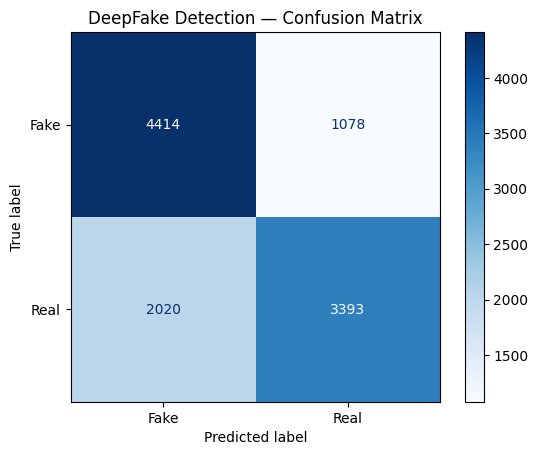

Saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
test_data2.reset()
preds = model2.predict(test_data2)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_data2.classes

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('DeepFake Detection — Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(true_labels, pred_labels, target_names=['Fake', 'Real'])
print(report)

# Save confusion matrix to Drive
import shutil
shutil.copy('confusion_matrix.png', '/content/drive/MyDrive/confusion_matrix.png')
print("Saved to Drive!")

              precision    recall  f1-score   support

        Fake       0.69      0.80      0.74      5492
        Real       0.76      0.63      0.69      5413

    accuracy                           0.72     10905
   macro avg       0.72      0.72      0.71     10905
weighted avg       0.72      0.72      0.71     10905

Saved to Drive!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.models import load_model

# Load old model
old_model = load_model('/content/drive/MyDrive/deepfake_checkpoint.h5', compile=False)

# Save in new format
old_model.save('/content/drive/MyDrive/deepfake_model_v2.keras')
print("Saved in new format!")

Mounted at /content/drive
Saved in new format!
